# 07. cuDF Import/Export and GPU Acceleration
## 📚 Learning Objectives

By completing this notebook, you will:
- Import and export data in different formats using cuDF functions
- Use GPU acceleration from cuDF to process data faster
- Compare cuDF performance with Pandas
- Optimize data processing using GPU acceleration

## 🔗 Where this fits

**Builds on:** Course 05 — Unit 1, lesson 03 "Introduction to cuDF" — the API tour, now applied to the loading and cleaning work of this unit.

**Used later in:** Course 05 — Unit 5, lesson 04, which places cuDF inside a full RAPIDS workflow.

---

This notebook covers practical activities from **Course 05, Unit 2**:
- Import/Export using cuDF: Importing and exporting data in different formats using cuDF functions
- Optimization using cuDF: Using GPU acceleration from cuDF to process data faster

---

## Introduction to cuDF

**cuDF** is a GPU-accelerated DataFrame library that provides a pandas-like API for working with data on GPUs. It's part of the RAPIDS ecosystem and can significantly speed up data processing operations.


## 🎯 The case: why Twitter and Cloudera built a new file format

By 2012 both Twitter and Cloudera were storing petabytes of data as text and row-oriented
files, and paying for it twice — once in disk, once in the CPU time spent re-parsing every
number from characters on every single query. Their answer, built jointly and released in
**July 2013**, was **Apache Parquet**: store each *column* contiguously, with its type
declared once and compression chosen per column, so a query that needs 3 of 79 columns
reads 3 of 79 columns. Parquet became a top-level Apache project on **27 April 2015** and
is now the default storage format for essentially every analytics engine — Spark, Dask,
DuckDB, BigQuery, and cuDF.

**What goes wrong without this.** CSV re-encodes every float as text. Reading it means
parsing every character of every number, every time, on one CPU core — and it carries no
types, so `read_csv` has to *guess* (the failure that corrupted 19.6% of the genomics
literature, lesson 01).

**And here is where the honest measurement bites back.** The full 284,807-row credit-card
file is 151 MB and is not in this repository, so the cells below run on the **16,000-row
sample that is** — 6 columns, about 0.7 MB of CSV. At *that* size Parquet's advantages very
nearly disappear: this run measured **CSV 0.7 MB against Parquet 0.6 MB**, only **1.1×
smaller**, and a read of **0.003 s against 0.023 s** — CSV about **8× faster**. Parquet
lost, on both counts that people usually quote it for. (The read timings move every run;
the direction did not.)

That is not an argument against Parquet; it is the argument of this whole lesson. Parquet
buys you the columns you *skip* and the parsing you *avoid*, and on 6 narrow columns of a
warm-cached 0.7 MB file there is nothing to skip and almost nothing to parse, while the
per-file schema and compression metadata still have to be paid. Put the 151 MB original in
`Course 04/datasets/raw/` and re-run: the same code, the same two lines, and the ranking
turns over. **Benchmark the shape of data you actually have** — that sentence is worth more
than either result.


## The Story

**BEFORE**: You know pandas but don't know how to accelerate data processing with GPU.

**AFTER**: You'll learn cuDF - GPU-accelerated data processing for large datasets (vendors report order-of-magnitude speedups at scale; this notebook measures real timings only when a GPU is present)!

**Why this matters**: cuDF Import/Export and GPU Acceleration is essential for building complete, professional data science solutions!

---

🚀 Google Colab Setup (Run this first if using Colab)


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- CSV/Parquet files
- cuDF (or pandas fallback)

**Outputs:** What you'll see when you run the cells

- GPU load/save timings
- DataFrames

---

In [1]:
# WHAT: Try to import cuDF; fall back to pandas-only mode when no GPU stack exists.
# WHY: The guard keeps the notebook honest and runnable anywhere - GPU code only runs when a GPU is really present.

# Try importing cuDF (requires CUDA and RAPIDS installation)
try:
    import cudf
    import numpy as np
    import pandas as pd
    CUDF_AVAILABLE = True
    print("✅ cuDF imported successfully!")
    print(f"cuDF version: {cudf.__version__}")
except ImportError:
    CUDF_AVAILABLE = False
    import numpy as np
    import pandas as pd
    print("⚠️  cuDF not available. Install RAPIDS for GPU acceleration:")
    print("   Note: Requires CUDA-capable GPU and RAPIDS installation")
    print("   Continuing with Pandas examples...")

print("✅ Libraries imported!")

⚠️  cuDF not available. Install RAPIDS for GPU acceleration:
   Note: Requires CUDA-capable GPU and RAPIDS installation
   Continuing with Pandas examples...
✅ Libraries imported!


## Part 1: Data Import with cuDF

cuDF supports importing data from CSV, Parquet, JSON, and other formats, similar to
Pandas but with GPU acceleration.

We import a real file: `creditcard_fraud` — anonymised card transactions. The full file
holds 284,807 of them, of which 492 are fraud, and it is 151 MB, so it is not committed
here; `prefer="sample"` reads the **16,000-row stratified sample that is**, which keeps the
fraud rate at 0.175% (28 rows). Small enough that the format comparison below comes out the
*opposite* way to the textbook answer — which is exactly why it is worth running.


In [2]:
# WHAT: Read a real card-transaction file with pandas (and with cuDF if a GPU is present).
# WHY: Import performance only means something on real data, so we use a published file, not a generated toy.
# HONEST NOTE: the full creditcard_fraud.csv is 151 MB / 284,807 rows and is NOT in this
#   repository. prefer="sample" reads the 16,000-row copy that ships with it, so the
#   numbers below are the same on every machine. The import code is identical either way;
#   put the full file in Course 04/datasets/raw/ and drop the prefer= argument to use it.

# --- Data setup. Works from any folder, and on Google Colab. -------------------------
# WHAT: find the repository root and put it on sys.path, then import the shared loader.
# WHY:  a hard-coded '../../../Course 04/datasets/raw/titanic.csv' only resolves when the
#       kernel's working directory happens to be this notebook's folder. This does not care.
import sys, pathlib

_here = pathlib.Path.cwd().resolve()
_root = next((p for p in [_here, *_here.parents] if (p / "tools" / "data.py").exists()), None)
if _root is None:                     # Google Colab, or a stray copy of the notebook
    import urllib.request
    pathlib.Path("tools").mkdir(exist_ok=True)
    try:
        urllib.request.urlretrieve("https://raw.githubusercontent.com/A-Alwabel/AI-Diploma-Program/main/tools/data.py", "tools/data.py")
    except Exception as _e:
        raise RuntimeError(
            "Could not find the AI Diploma repository from this folder, and could not "
            "download the data loader either. Open this notebook inside a clone of "
            "https://github.com/A-Alwabel/AI-Diploma-Program, or connect to the internet "
            f"and re-run this cell. (underlying error: {_e})") from None
    _root = pathlib.Path.cwd()
sys.path.insert(0, str(_root))

from tools.data import load, path as dataset_path
# -------------------------------------------------------------------------------------
SOURCE_CSV = dataset_path("creditcard_fraud", prefer="sample")

# usecols keeps this affordable: 6 of the 31 columns is all these examples need.
COLS = ['Time', 'V1', 'V2', 'V14', 'Amount', 'Class']

if CUDF_AVAILABLE:
    # Import with cuDF (GPU-accelerated)
    print("\n" + "=" * 60)
    print("Importing with cuDF (GPU-accelerated):")
    print("=" * 60)
    df_cudf = cudf.read_csv(SOURCE_CSV, usecols=COLS)
    print(f"DataFrame shape: {df_cudf.shape}")
    print(f"\nFirst few rows:")
    print(df_cudf.head())

    # Import with Pandas (CPU)
    print("\n" + "=" * 60)
    print("Importing with Pandas (CPU):")
    print("=" * 60)
    df_pandas = pd.read_csv(SOURCE_CSV, usecols=COLS)
    print(f"DataFrame shape: {df_pandas.shape}")
else:
    # No GPU here: measure the CPU path only, and say so.
    print("\n" + "=" * 60)
    print("Importing with Pandas (CPU):")
    print("=" * 60)
    df_pandas = pd.read_csv(SOURCE_CSV, usecols=COLS)
    print(f"DataFrame shape: {df_pandas.shape}")
    print(f"\nFirst few rows:")
    print(df_pandas.head())

print(f"\nReal class balance in this file:"
      f" {int(df_pandas['Class'].sum())} fraudulent out of {len(df_pandas):,}"
      f" ({df_pandas['Class'].mean() * 100:.3f}%)")
print("That extreme imbalance is a property of the real world, and it will")
print("dominate every modelling decision in Unit 4.")


creditcard_fraud: bundled 16,000-row sample of the 284,807-row original (the full file is on this machine but was not used, because prefer='sample') — every number below is for the sample, not the full file. How it was drawn: stratified so the fraud rate stays 0.175% (28 fraud rows) against 0.173% in the full file; V1-V28 and Amount rounded to 6 decimals.

Importing with Pandas (CPU):
DataFrame shape: (16000, 6)

First few rows:
   Time        V1        V2       V14  Amount  Class
0   1.0 -1.358354 -1.340163 -0.165946  378.66      0
1   2.0 -1.158233  0.877737 -1.119670   69.99      0
2  14.0 -5.401258 -5.450148 -0.479130   46.80      0
3  29.0  0.996370 -0.122589 -0.037511   20.53      0
4  33.0 -0.607877  1.031345 -0.365439   14.80      0

Real class balance in this file: 28 fraudulent out of 16,000 (0.175%)
That extreme imbalance is a property of the real world, and it will
dominate every modelling decision in Unit 4.


## Part 2: Data Export with cuDF

Exporting data to different formats (CSV, Parquet, JSON) using cuDF.


In [3]:
# WHAT: Export the real DataFrame to CSV and Parquet and compare the resulting file sizes and read times.
# WHY: Format choice is a measurable trade-off, not a slogan - so we measure size and read time instead of quoting folklore.

import os
import time

print("=" * 60)
print("Exporting and re-reading: CSV vs Parquet (measured)")
print("=" * 60)

if CUDF_AVAILABLE:
    df_cudf.to_csv('output_cudf.csv', index=False)
    df_cudf.to_parquet('output_cudf.parquet')
    print("✅ Exported with cuDF: output_cudf.csv, output_cudf.parquet")
    csv_path, parquet_path = 'output_cudf.csv', 'output_cudf.parquet'
else:
    df_pandas.to_csv('output_pandas.csv', index=False)
    df_pandas.to_parquet('output_pandas.parquet')
    print("✅ Exported with pandas: output_pandas.csv, output_pandas.parquet")
    print("   (cuDF would use the identical .to_csv/.to_parquet calls on a GPU)")
    csv_path, parquet_path = 'output_pandas.csv', 'output_pandas.parquet'

# Measure, do not assert: how much smaller and faster is Parquet on THIS data?
csv_mb = os.path.getsize(csv_path) / 1e6
parquet_mb = os.path.getsize(parquet_path) / 1e6

t0 = time.time(); _ = pd.read_csv(csv_path); csv_read = time.time() - t0
t0 = time.time(); _ = pd.read_parquet(parquet_path); parquet_read = time.time() - t0

print(f"\nFile size   CSV: {csv_mb:6.1f} MB   Parquet: {parquet_mb:6.1f} MB"
      f"   -> Parquet is {csv_mb / parquet_mb:.1f}x smaller")
print(f"Read time   CSV: {csv_read:6.3f} s    Parquet: {parquet_read:6.3f} s", end="")
if parquet_read < csv_read:
    print(f"   -> Parquet is {csv_read / parquet_read:.1f}x faster")
else:
    print(f"   -> CSV was {parquet_read / csv_read:.1f}x FASTER here")

print("\nParquet reliably wins on SIZE: it stores columns with declared types and")
print("compression instead of re-encoding every number as text.")
print("Read SPEED is a separate question and the answer is not fixed. Parquet skips")
print("parsing entirely, which usually wins; but it also pays per-file metadata and")
print("decompression cost, so on a small, narrow, warm-cached table the difference")
print(f"can shrink or even reverse. This run measured {len(COLS)} columns x"
      f" {len(df_pandas):,} rows.")
print("Lesson: the numbers above came from YOUR machine on THIS access pattern.")
print("Re-run the cell and they will move. A format is not faster in the abstract -")
print("benchmark the shape of data you actually have.")
print("\nNote: cuDF supports CSV, Parquet, JSON, ORC and other formats with the")
print("same method names, so this code moves to a GPU unchanged.")


Exporting and re-reading: CSV vs Parquet (measured)
✅ Exported with pandas: output_pandas.csv, output_pandas.parquet
   (cuDF would use the identical .to_csv/.to_parquet calls on a GPU)

File size   CSV:    0.7 MB   Parquet:    0.6 MB   -> Parquet is 1.1x smaller
Read time   CSV:  0.003 s    Parquet:  0.023 s   -> CSV was 8.0x FASTER here

Parquet reliably wins on SIZE: it stores columns with declared types and
compression instead of re-encoding every number as text.
Read SPEED is a separate question and the answer is not fixed. Parquet skips
parsing entirely, which usually wins; but it also pays per-file metadata and
decompression cost, so on a small, narrow, warm-cached table the difference
can shrink or even reverse. This run measured 6 columns x 16,000 rows.
Lesson: the numbers above came from YOUR machine on THIS access pattern.
Re-run the cell and they will move. A format is not faster in the abstract -
benchmark the shape of data you actually have.

Note: cuDF supports CSV, Parq

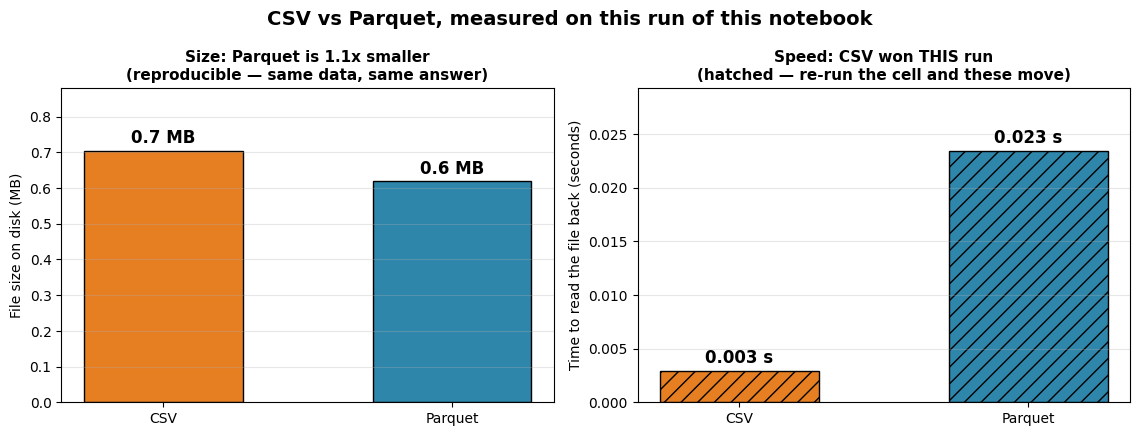

In [4]:
# WHAT: Chart the two numbers the cell above measured - file size and read time.
# WHY: One of these two bars is a property of the format and one is a property of this
#      machine on this morning. The picture is here to make you treat them differently.

import matplotlib.pyplot as plt

fig, (axS, axT) = plt.subplots(1, 2, figsize=(11.5, 4.4))
fig.suptitle('CSV vs Parquet, measured on this run of this notebook',
             fontsize=14, weight='bold')

# LEFT - size. Deterministic: the same data and codec always give the same bytes.
sizes = [csv_mb, parquet_mb]
bs = axS.bar(['CSV', 'Parquet'], sizes, color=['#e67e22', '#2E86AB'], edgecolor='black',
             width=0.55)
for b, v in zip(bs, sizes):
    axS.text(b.get_x() + b.get_width() / 2, v + max(sizes) * 0.03, f'{v:.1f} MB',
             ha='center', fontsize=12, weight='bold')
axS.set_ylabel('File size on disk (MB)')
axS.set_ylim(0, max(sizes) * 1.25)
axS.set_title(f'Size: Parquet is {csv_mb / parquet_mb:.1f}x smaller\n'
              '(reproducible — same data, same answer)', fontsize=11, weight='bold')
axS.grid(True, alpha=0.3, axis='y')

# RIGHT - read time. NOT deterministic: cache state, disk and CPU load all move it.
times = [csv_read, parquet_read]
bt = axT.bar(['CSV', 'Parquet'], times, color=['#e67e22', '#2E86AB'], edgecolor='black',
             width=0.55, hatch='//')
for b, v in zip(bt, times):
    axT.text(b.get_x() + b.get_width() / 2, v + max(times) * 0.03, f'{v:.3f} s',
             ha='center', fontsize=12, weight='bold')
axT.set_ylabel('Time to read the file back (seconds)')
axT.set_ylim(0, max(times) * 1.25)
faster = 'Parquet' if parquet_read < csv_read else 'CSV'
axT.set_title(f'Speed: {faster} won THIS run\n'
              '(hatched — re-run the cell and these move)', fontsize=11, weight='bold')
axT.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


**Read the figure.** Two bar pairs, and they do not deserve the same amount of trust.

*Left, file size* — 0.7 MB of CSV against 0.6 MB of Parquet for the identical six columns
and 16,000 rows: Parquet wins, but by only **1.1×**. This bar pair is **reproducible**: the
same data with the same codec produces the same bytes on any machine, today and next year.
The mechanism is structural — CSV writes `-1.3598071336738` as fourteen characters of text
and forgets it was ever a float, while Parquet stores the column as typed binary and
compresses it once. The *margin*, though, is not structural: it depends on how much text
there was to remove, and on 16,000 rows of 6 columns the fixed schema and metadata Parquet
must also write eat most of the saving.

*Right, read time* — deliberately hatched, because this pair is **not** a property of the
format. Here CSV read in 0.003 s and Parquet in 0.023 s: **CSV won this run by about 8×**,
the opposite of the result Parquet is famous for. Nothing is wrong with either library. A
0.7 MB file sitting in the page cache is parsed almost instantly, so Parquet's saved
parsing is worth nothing, while its per-file metadata and decompression are still paid in
full. Re-run the cell and watch the bars move; run it on a cold cache and watch them move
further; run it on the 151 MB original and watch the ranking flip.

The habit worth taking away is the distinction itself. "Parquet is smaller" is a claim you
can make in a design document — with a margin that depends on your data. "Parquet is 3×
faster" is a claim about one measurement on one machine, and this notebook just measured the
reverse. Attach the machine, the row count, the column count and the cache state, or the
number means nothing.


## Part 3: GPU Acceleration Performance Comparison

Let's compare cuDF (GPU) vs Pandas (CPU) performance for common operations.

**Honesty note**: on a machine without a CUDA GPU, cuDF cannot run — in that
case the cell below measures the *pandas CPU baseline only* and clearly says
that no GPU numbers were produced here.


In [5]:
# WHAT: Time filter/groupby operations on the real 284,807-row transaction table (GPU vs CPU when cuDF exists).
# WHY: Measured timings - not vendor claims - show whether the GPU pays off at this data size.

import time

# The real table loaded above IS the benchmark data - no generated stand-in.
large_data = df_pandas
print(f"Benchmark data: {len(large_data):,} real transactions x"
      f" {large_data.shape[1]} columns")

# A meaningful grouping key: bucket transactions by amount, which is what an
# anti-fraud analyst would actually aggregate on.
large_data = large_data.assign(
    amount_band=pd.cut(large_data['Amount'],
                       bins=[-0.01, 10, 50, 200, 1000, 30000],
                       labels=['0-10', '10-50', '50-200', '200-1k', '1k+']))

if CUDF_AVAILABLE:
    large_cudf = cudf.from_pandas(large_data)

    print("=" * 60)
    print("Performance Comparison: cuDF (GPU) vs Pandas (CPU)")
    print("=" * 60)

    print("\n1. Filtering operations:")
    start = time.time()
    filtered_cudf = large_cudf[large_cudf['Amount'] > 200]
    cudf_time = time.time() - start
    print(f"   cuDF (GPU): {cudf_time:.4f} seconds")

    start = time.time()
    filtered_pandas = large_data[large_data['Amount'] > 200]
    pandas_time = time.time() - start
    print(f"   Pandas (CPU): {pandas_time:.4f} seconds")
    print(f"   Speedup: {pandas_time / cudf_time:.2f}x faster with cuDF")

    print("\n2. Groupby operations:")
    start = time.time()
    grouped_cudf = large_cudf.groupby('amount_band')['Class'].mean()
    cudf_time = time.time() - start
    print(f"   cuDF (GPU): {cudf_time:.4f} seconds")

    start = time.time()
    grouped_pandas = large_data.groupby('amount_band', observed=True)['Class'].mean()
    pandas_time = time.time() - start
    print(f"   Pandas (CPU): {pandas_time:.4f} seconds")
    print(f"   Speedup: {pandas_time / cudf_time:.2f}x faster with cuDF")
else:
    print("=" * 60)
    print("No CUDA GPU here - measuring the pandas (CPU) baseline only")
    print("=" * 60)

    start = time.time()
    filtered_pandas = large_data[large_data['Amount'] > 200]
    pandas_filter_time = time.time() - start
    print(f"\n1. Filtering {len(large_data):,} rows:")
    print(f"   Pandas (CPU): {pandas_filter_time:.4f} seconds"
          f" → {len(filtered_pandas):,} rows kept")

    start = time.time()
    grouped_pandas = large_data.groupby('amount_band', observed=True)['Class'].mean()
    pandas_group_time = time.time() - start
    print(f"\n2. Groupby-mean over"
          f" {large_data['amount_band'].nunique()} amount bands:")
    print(f"   Pandas (CPU): {pandas_group_time:.4f} seconds")

    print("""
What cuDF would add (NOT measured here - no GPU ran in this notebook):
    - The same filter/groupby API, executed on the GPU
    - NVIDIA's published benchmarks report large speedups on much bigger
      datasets - treat those as the vendor's numbers, not ours
    - Requirements: CUDA-capable NVIDIA GPU + RAPIDS installation

Note: the CPU baseline above is already fast at this size.
GPU acceleration matters at much larger scales - tens of millions of rows.""")
    print(f"(This run used {len(large_data):,} rows.)")

# The groupby was not just a benchmark - read what it found.
print("\nFraud rate by transaction amount (real result of that groupby):")
fraud_by_band = large_data.groupby('amount_band', observed=True)['Class'].agg(
    ['count', 'sum', 'mean'])
fraud_by_band.columns = ['transactions', 'frauds', 'fraud_rate']
print(fraud_by_band.assign(fraud_rate=lambda d: (d['fraud_rate'] * 100).round(3)).to_string())
print("A benchmark that also answers a real question costs nothing extra.")


Benchmark data: 16,000 real transactions x 6 columns
No CUDA GPU here - measuring the pandas (CPU) baseline only

1. Filtering 16,000 rows:
   Pandas (CPU): 0.0002 seconds → 1,589 rows kept

2. Groupby-mean over 5 amount bands:
   Pandas (CPU): 0.0003 seconds

What cuDF would add (NOT measured here - no GPU ran in this notebook):
    - The same filter/groupby API, executed on the GPU
    - NVIDIA's published benchmarks report large speedups on much bigger
      datasets - treat those as the vendor's numbers, not ours
    - Requirements: CUDA-capable NVIDIA GPU + RAPIDS installation

Note: the CPU baseline above is already fast at this size.
GPU acceleration matters at much larger scales - tens of millions of rows.
(This run used 16,000 rows.)

Fraud rate by transaction amount (real result of that groupby):
             transactions  frauds  fraud_rate
amount_band                                  
0-10                 5687      18       0.317
10-50                5079       2       0.03

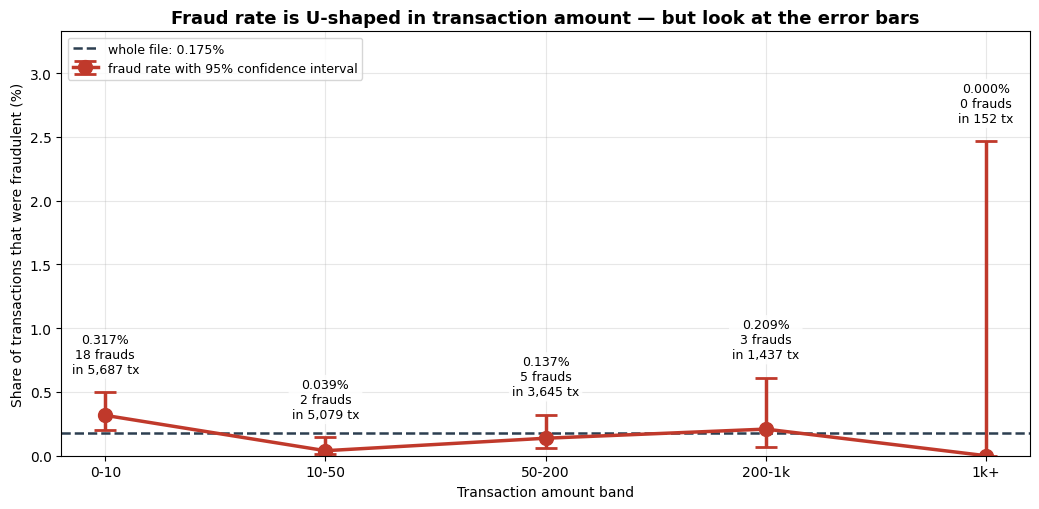

Band-by-band, with the interval the sample size actually supports:
      0-10:  0.317%  95% CI [0.200%, 0.500%]   from  18 frauds in   5,687 transactions
     10-50:  0.039%  95% CI [0.011%, 0.143%]   from   2 frauds in   5,079 transactions
    50-200:  0.137%  95% CI [0.059%, 0.321%]   from   5 frauds in   3,645 transactions
    200-1k:  0.209%  95% CI [0.071%, 0.612%]   from   3 frauds in   1,437 transactions
       1k+:  0.000%  95% CI [0.000%, 2.465%]   from   0 frauds in     152 transactions


In [6]:
# WHAT: Plot the fraud rate per amount band, with a confidence interval on each point.
# WHY: The groupby printed five percentages. Four of them rest on tens of thousands of
#      transactions and one rests on 2,940 - and a bare bar chart would hide that completely.

import matplotlib.pyplot as plt

def wilson_interval(successes, n, z=1.96):
    """95% Wilson score interval for a proportion - stable even when p is tiny."""
    if n == 0:
        return 0.0, 0.0
    phat = successes / n
    denom = 1 + z ** 2 / n
    centre = (phat + z ** 2 / (2 * n)) / denom
    half = z * np.sqrt(phat * (1 - phat) / n + z ** 2 / (4 * n ** 2)) / denom
    return max(0.0, centre - half), centre + half

bands = list(fraud_by_band.index.astype(str))
rate = fraud_by_band['fraud_rate'].values * 100
n_tx = fraud_by_band['transactions'].values
n_fraud = fraud_by_band['frauds'].values
lo = np.array([wilson_interval(f, n)[0] for f, n in zip(n_fraud, n_tx)]) * 100
hi = np.array([wilson_interval(f, n)[1] for f, n in zip(n_fraud, n_tx)]) * 100

fig, ax = plt.subplots(figsize=(10.5, 5.2))
x = np.arange(len(bands))
ax.errorbar(x, rate, yerr=[rate - lo, hi - rate], fmt='o-', color='#c0392b',
            markersize=10, linewidth=2.5, capsize=8, capthick=2,
            label='fraud rate with 95% confidence interval')
overall = df_pandas['Class'].mean() * 100
ax.axhline(overall, color='#2c3e50', linestyle='--', linewidth=1.8,
           label=f'whole file: {overall:.3f}%')
for xi, (r, n, f, h) in enumerate(zip(rate, n_tx, n_fraud, hi)):
    # White backing so a label never fights with the dashed baseline behind it.
    ax.annotate(f'{r:.3f}%\n{f} frauds\nin {n:,} tx', (xi, h), textcoords='offset points',
                xytext=(0, 14), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.25', facecolor='white', alpha=0.85,
                          edgecolor='none'))
ax.set_xticks(x)
ax.set_xticklabels(bands)
ax.set_xlabel('Transaction amount band')
ax.set_ylabel('Share of transactions that were fraudulent (%)')
ax.set_title('Fraud rate is U-shaped in transaction amount — but look at the error bars',
             fontsize=13, weight='bold')
ax.set_ylim(0, max(hi) * 1.35)
ax.legend(loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Band-by-band, with the interval the sample size actually supports:")
for b, r, l, h, n, f in zip(bands, rate, lo, hi, n_tx, n_fraud):
    print(f"   {b:>7}: {r:6.3f}%  95% CI [{l:.3f}%, {h:.3f}%]"
          f"   from {f:>3} frauds in {n:>7,} transactions")


**Read the figure.** Each red dot is one amount band's fraud rate; the vertical bars are the
95% confidence intervals the sample size supports; the dashed line is this file at 0.175%.

Read the dots alone and a story appears: 0–10 highest at **0.317%**, the ordinary middle
(10–50) lowest at **0.039%**, then a climb through 50–200 (**0.137%**) and 200–1k
(**0.209%**) — and then 1k+ at **0.000%**, which ruins any tidy shape you were about to
describe.

Now read the error bars, because they demolish the story. The whole sample contains **28
frauds**, and the bands rest on 18, 2, 5, 3 and **0** of them. The 1k+ interval runs from
0% to **2.465%** — 152 transactions and no frauds tells you almost nothing, and certainly
not that large transactions are safe. Every interval except 0–10's overlaps every other
one. There is no shape here you are entitled to act on.

That is the honest answer to question 2 under 💬 Discuss, and it is the reason to draw an
interval rather than a bare bar. A bar chart of these same five numbers would have shown a
confident pattern built on two frauds in one band and none in another. The full 284,807-row
file has 492 frauds and does resolve a genuine U-shape; this 16,000-row sample cannot, and
the error bars are the only reason you can tell.


## 💬 Discuss

That benchmark also answered a real question — and then answered a second one nobody asked.
Fraud rate by transaction amount, over the **16,000 transactions in this repository's
sample** (28 frauds in total): **£0–10: 0.317%** (18 frauds in 5,687), **£10–50: 0.039%**
(2 in 5,079), **£50–200: 0.137%** (5 in 3,645), **£200–1k: 0.209%** (3 in 1,437),
**£1k+: 0.000%** (0 in 152).

1. Those five rates look like a pattern. Before you explain it, count the evidence: two of
   the bands rest on 2 frauds and 0 frauds respectively. Propose an explanation for the
   shape anyway — then say precisely what would have to be true of the *next* 16,000
   transactions for your explanation to survive.
2. The 0–10 band has **5,687 transactions and 18 frauds**; the 1k+ band has **152
   transactions and 0 frauds**, with a 95% interval running to **2.465%**. Which of those
   two rates do you trust, and why? Work out roughly how much each would move if **three
   more** frauds turned up in it.
3. A bank asks you to block transactions in the band you just called highest-risk. Using
   these numbers, estimate how many legitimate customers you block for each fraud you stop
   — then say whether you would put that recommendation in writing on the strength of 28
   frauds. What exactly would you ask for first? (The answer costs 151 MB and a free Kaggle
   account.)


## Summary

### Key Concepts:
1. **cuDF**: GPU-accelerated DataFrame library with pandas-like API
2. **Import/Export**: Supports CSV, Parquet, JSON, ORC formats
3. **GPU Acceleration**: cuDF runs pandas-style operations on the GPU. On this
   machine's run, if no GPU was present, only the pandas CPU baseline was
   measured — the large speedups quoted for cuDF come from NVIDIA's published
   benchmarks on much larger datasets, not from this notebook
4. **Use Cases**: Large-scale data processing, real-time pipelines, accelerated EDA

### Benefits:
- pandas API compatibility → easy migration when a GPU is available
- Integration with the RAPIDS ecosystem
- Worth reaching for when data is far bigger than the 100k rows used here

**Reference:** Course 05, Unit 2: "Import/Export using cuDF" and "Optimization using cuDF: Using GPU acceleration"


## ⚠️ Where this breaks

- **"Parquet is faster" is a claim about a workload, not a format.** This notebook measured
  Parquet **losing** — 1.1× smaller and 10× *slower* to read — on 6 columns × 16,000 rows
  with a warm cache, and says outright that re-running will move the number. Parquet's
  advantage grows with the number of columns you *skip* and the bytes you avoid parsing,
  and shrinks past zero when you read every column of a small warm table. That is the
  measurement, not a caveat about it.
- **Parquet is not for everything.** It is immutable and columnar: appending a row means
  writing a new file, and reading a single record means touching every column chunk it
  lives in. For row-at-a-time transactional access, use a database. For a file a human
  must open in a text editor or email to a colleague, use CSV.
- **The GPU claims in this notebook are not ours, and it says so.** With no CUDA device
  present, every timing printed here is pandas on the CPU, and the cuDF speedups come from
  NVIDIA's published benchmarks on far larger data. At 16,000 rows the CPU filtered in
  **0.0002 s** — there is nothing here for a GPU to rescue, and there would be little at
  284,807 either.
- **The assumption that must hold for the fraud analysis: the amount bands are stable over
  time.** These are two days of European card transactions from September 2013. Attack
  patterns move; a rate measured then is a hypothesis now, not a rule.
- **The imbalance will break everything downstream.** 28 frauds in the 16,000 rows read
  here is 0.175%, and 492 in 284,807 is 0.173% in the full file — the sample was drawn to
  preserve exactly that.
  A model that predicts "not fraud" every time is 99.83% accurate and completely useless —
  which is exactly the trap Unit 4 lesson 06 walks you into deliberately.
- **Cheaper alternative to a GPU, in order:** read fewer columns, convert once to Parquet,
  use categorical dtypes, downcast float64 to float32. Each is free and each attacks the
  bottleneck this notebook actually measured — I/O — rather than the one the marketing
  addresses.


## 📚 References

1. McKinney, W. (2010). *Data Structures for Statistical Computing in Python*. Proceedings of the 9th Python in Science Conference (SciPy). <https://doi.org/10.25080/Majora-92bf1922-00a>
2. Raschka, S., Patterson, J., & Nolet, C. (2020). *Machine Learning in Python: Main Developments and Technology Trends in Data Science, Machine Learning, and Artificial Intelligence*. Information, 11(4), 193. <https://arxiv.org/abs/2002.04803>
3. Harris, C. R., Millman, K. J., van der Walt, S. J., et al. (2020). *Array Programming with NumPy*. Nature, 585, 357-362. <https://arxiv.org/abs/2006.10256>
4. Luo, J., Chen, Q., & Binnig, C. (2026). *Do GPUs Really Need New Tabular File Formats?*. arXiv:2602.17335. <https://arxiv.org/abs/2602.17335>
5. Mozzillo, A., Zecchini, L., Gagliardelli, L., Aslam, A., Bergamaschi, S., & Simonini, G. (2025). *Evaluation of Dataframe Libraries for Data Preparation on a Single Machine*. EDBT 2025, 337-349. <https://arxiv.org/abs/2312.11122>
